# we are going to use generative models to predict not only the energy, but other important features. 

Our input: 
for epoch in total iterations:

> 1. NXM matrix where N is the number of hours we are considering, M is the number of features that are highly correlated and are numbers. 
> 2. Generator: We can use either a DNN, CNN or transformers
> 3. Output: G(NxM) = 1xM -> which means it predicts the features.
> 4. activation function for each layer is dependant on our prior knowledge of our feature.  
> 5. During training: the loss is between the prediction and the N+1 th hour.

Finally: after the training, we will move to the right by one hour and train on the next matrix. This goes on and on.  

In [236]:
import pandas as pd
from sklearn.model_selection import train_test_split
path = '/data/hereon/wp/user/hailudaw/git_folders/paper_selfphish/smrl/forcast/participant_package/physics-exe/outputs/preprocessed_dataset/trainval_hourly_base.csv'#'/data/hereon/wp/user/hailudaw/git_folders/paper_selfphish/smrl/forcast/participant_package/work/output/audit_table.csv'
df = pd.read_csv(path)
df.keys()

Index(['source_timestamp_utc', 'effective_timestamp_utc', 'sequence_index',
       'label_power_kw', 'was_gap_shifted', 'was_dst_adjusted', 'hour_of_day',
       'day_of_week', 'day_of_year', 'month', 'season', 'is_weekend',
       'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'day_of_year_sin',
       'day_of_year_cos', 'month_sin', 'month_cos', 'weather_history_expected',
       'weather_history_complete', 'weather_history_expected_feature_count',
       'weather_history_available_feature_count',
       'weather_history_available_fraction'],
      dtype='object')

In [172]:
# do the correlation for the power_kw vs others and rank them in order of correlation
correlations = {}
for column in df.columns:
    if column != 'source_timestamp_utc' and column != 'effective_timestamp_utc' or column != 'timestamp':
        try:
            corr = df['power_kw'].corr(df[column])
            correlations[column] = corr
        except Exception as e:
            print(f"Could not compute correlation between power_kw and {column}: {e}")
#sort the correlations in descending order
sorted_correlations = dict(sorted(correlations.items(), key=lambda item: abs(item[1]), reverse=True))
# remove the weak correlation which are below 0.2
strong_correlations = {k: v for k, v in sorted_correlations.items() if abs(v) >= 0.4}
strong_correlations

Could not compute correlation between power_kw and timestamp: could not convert string to float: '2025-01-01 00:00:00'
Could not compute correlation between power_kw and imputation_method: could not convert string to float: 'observed'
Could not compute correlation between power_kw and timestamp_utc: could not convert string to float: '2025-01-01T00:00:00Z'
Could not compute correlation between power_kw and source_timestamp_utc: could not convert string to float: '2025-01-01T00:00:00Z'
Could not compute correlation between power_kw and season_bucket: could not convert string to float: 'winter'


/data/hereon/wp/user/hailudaw/mamba/envs/smrl/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/data/hereon/wp/user/hailudaw/mamba/envs/smrl/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


{'power_kw': np.float64(1.0),
 'active_container_count': np.float64(0.7945540282802586),
 'share_stack_tier_1': np.float64(-0.6005406355039745),
 'mean_stack_tier': np.float64(0.5672143807643095),
 'share_stack_tier_3': np.float64(0.48840156794970485),
 'share_stack_tier_2': np.float64(0.46842406411178167),
 'mean_ambient_minus_setpoint_c': np.float64(0.4100055605723357)}

In [181]:
# our new data
new_df = df[ ['timestamp']+['power_kw']+list(strong_correlations.keys())]
# add a new column timeid for integer
new_df['timeid'] = range(len(new_df))
# if there is a doubled column, remove it   
new_df = new_df.loc[:,~new_df.columns.duplicated()]
new_df

/tmp/ipykernel_2353373/3165440733.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['timeid'] = range(len(new_df))


,timestamp,power_kw,active_container_count,share_stack_tier_1,mean_stack_tier,share_stack_tier_3,share_stack_tier_2,mean_ambient_minus_setpoint_c,timeid
0,2025-01-01 00:00:00,843.247345,425.0,0.461176,1.760000,0.221176,0.317647,7.537608,0
1,2025-01-01 01:00:00,866.865919,425.0,0.461176,1.760000,0.221176,0.317647,8.104608,1
2,2025-01-01 02:00:00,865.292780,425.0,0.461176,1.760000,0.221176,0.317647,8.418302,2
3,2025-01-01 03:00:00,875.907910,425.0,0.461176,1.760000,0.221176,0.317647,8.563702,3
4,2025-01-01 04:00:00,873.150000,425.0,0.461176,1.760000,0.221176,0.317647,9.103969,4
...,...,...,...,...,...,...,...,...,...
8978,2026-01-10 02:00:00,978.744163,598.0,0.418060,1.834448,0.252508,0.329431,-0.779816,8978
8979,2026-01-10 03:00:00,1004.226512,629.0,0.400636,1.869010,0.270270,0.324324,-1.320647,8979
8980,2026-01-10 04:00:00,1028.173913,630.0,0.401587,1.868045,0.269841,0.326984,-1.380439,8980
8981,2026-01-10 05:00:00,1027.478987,638.0,0.404389,1.863636,0.268025,0.327586,-1.720906,8981


In [213]:
batch_size = 1
batches = []
test = []
# training data is all data that don't have 2026 in their timestamp, which is the last 24 hours of data
train_data = new_df[~new_df['timestamp'].str.contains('2026')]
test_data = new_df[new_df['timestamp'].str.contains('2026')]
for start in range(0, len(train_data) - batch_size + 1, 1):
    batch = train_data.iloc[start:start + batch_size]
    timestamp = batch['timestamp']
    timeid = batch['timeid']
    batch = batch.drop(columns=['timestamp', 'timeid'])
    batches.append(batch.values)

# batches[0], timestamp, timeid

In [214]:
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
# our simple model: the input is the current power_kw and the output is 1. 
# our neural network will be trained on the first 24 hours, then tested on the next hour, then trained on the next 24 hours, and so on. This way we can use all the data for training and testing, and also we can test on the data that is not seen during training.
config = {
    'input_size': 1, # the number of features, which is the number of strong correlations + 1 for the power_kw
    'output_size': 1, # the number of output neurons, which is 1 for the power_kw
    'hidden_size': 16, # the number of neurons in the hidden layer
    'num_epochs': 1000, # the number of epochs to train the model
    'learning_rate': 0.001 # the learning rate for the optimizer
}

def generator_model_architecture(config):
    import torch
    import torch.nn as nn
    class Generator(nn.Module):
        def __init__(self, config):
            super(Generator, self).__init__()
            self.fc1 = nn.Linear(config['input_size'], config['hidden_size'])
            self.fc2 = nn.Linear(config['hidden_size'], config['output_size'])
            self.relu = nn.ReLU()
        def forward(self, x):
            x = self.relu(self.fc1(x))
            x = self.fc2(x)
            return x
    return Generator(config)
from tqdm import tqdm
# we will train the model on the first 24 hours, then test on the next hour, then train on the next 24 hours, and so on. This way we can use all the data for training and testing, and also we can test on the data that is not seen during training.
pbar = tqdm(range(len(batches) - 1), desc='Training batches')
stopping_criterion = 1e-8
for i in pbar: #range(len(batches) - 1):
    power_kw = batches[i][:, 0:1] # the first column is the power_kw
    power_pred = batches[i+1][:, 0:1] # the next hour's power_kw is the target for prediction
    features = batches[i][:, 1:] # the rest of the columns are the features
    model = generator_model_architecture(config)
    torch.compile(model)
    criterion = nn.L1Loss()
    feature_params =[nn.Parameter(torch.tensor(1e-5, dtype=torch.float32), requires_grad=True) for _ in range(len(features[0]))]
    feature_optimizer = [torch.optim.Adam([param], lr=config['learning_rate']) for param in feature_params]
    optimizer = torch.optim.Adam(model.parameters(), lr=config['learning_rate'])
    losses = []
    # pbar = tqdm(range(config['num_epochs']), desc=f'Training on batch {i+1}/{len(batches)-1}')
    for epoch in range(config['num_epochs']):
        loss = 0
        optimizer.zero_grad()
        for param_optimizer in feature_optimizer:
            param_optimizer.zero_grad()
        model.train()
        inputs = torch.tensor(power_kw, dtype=torch.float32)
        targets = torch.tensor(power_pred, dtype=torch.float32).view(-1, 1)
        outputs = model(inputs) + sum([torch.relu(feature_params[j]).clamp(1e-8,1e-5) * torch.tensor(features[:, j], dtype=torch.float32).view(-1, 1) for j in range(len(features))])
        loss = criterion(outputs, targets)
        optimizer.zero_grad()
        loss.backward()

        optimizer.step()
        for param_optimizer in feature_optimizer:
            param_optimizer.step()
        losses.append(loss.item())
        # pbar.set_postfix({'loss': loss.item(), 'pred': outputs.detach().numpy()[0][0], 'true': targets.numpy()[0][0], 'feature_weights': [param.item() for param in feature_params]})
        if epoch > 10 and loss.item() < stopping_criterion:
            break

    # pbar.close()
    if i == 2:
        stopping_criterion = loss.item()
    
    pbar.set_postfix({'loss': loss.item(), 'pred': outputs.detach().numpy()[0][0], 'true': targets.numpy()[0][0], 'feature_weights': [param.item() for param in feature_params]})
pbar.close()

Training batches: 100%|██████████| 8759/8759 [17:58<00:00,  8.12it/s, loss=0.182, pred=950, true=950, feature_weights=[0.0060155075043439865, 9.999999747378752e-06, 9.999999747378752e-06, 9.999999747378752e-06, 9.999999747378752e-06, 9.999999747378752e-06]]           


In [240]:
# the test data:
batch_size = batch_size
test_batches = []
time_stamps = []

for start in range(0, len(test_data) - batch_size + 1, 1):
    batch = test_data.iloc[start:start + batch_size]
    timestamp = batch['timestamp']
    timeid = batch['timeid']
    batch = batch.drop(columns=['timestamp', 'timeid'])
    test_batches.append(batch.values)
    time_stamps.append(timestamp)


predictions_for_january = {}
predictions_for_january_90 = {}
# we will test the model on the test batches and print the predictions and the true values
for i in range(len(test_batches) - 1):
    power_kw = test_batches[i][:, 0:1] # the first column is the power_kw
    power_pred = test_batches[i+1][:, 0:1] # the next hour's power_kw is the target for prediction
    features = test_batches[i][:, 1:] # the rest of the columns are the features
    model.eval()
    inputs = torch.tensor(power_kw, dtype=torch.float32)
    targets = torch.tensor(power_pred, dtype=torch.float32).view(-1, 1)
    outputs = model(inputs) #+ sum([torch.relu(feature_params[j]).clamp(1e-8,1e-5) * torch.tensor(features[:, j], dtype=torch.float32).view(-1, 1) for j in range(len(features))])
    outputs_90 = outputs + 1/10*outputs
    print("our input was: ", power_kw, "and our prediction is: ", outputs.detach().numpy(), "and the true value is: ", power_pred)
    predictions_for_january[time_stamps[i+1].values[0]] = {}
    predictions_for_january[time_stamps[i+1].values[0]]['predicted_power_kw'] = outputs.detach().numpy()[0][0]
    predictions_for_january[time_stamps[i+1].values[0]]['true_power_kw'] = power_pred[0][0]
    predictions_for_january_90[time_stamps[i+1].values[0]] = {}
    predictions_for_january_90[time_stamps[i+1].values[0]]['predicted_power_kw'] = outputs_90.detach().numpy()[0][0]
    predictions_for_january_90[time_stamps[i+1].values[0]]['true_power_kw'] = power_pred[0][0]

our input was:  [[943.31908441]] and our prediction is:  [[938.64825]] and the true value is:  [[929.78849646]]
our input was:  [[929.78849646]] and our prediction is:  [[925.1918]] and the true value is:  [[929.39437658]]
our input was:  [[929.39437658]] and our prediction is:  [[924.7998]] and the true value is:  [[935.28405303]]
our input was:  [[935.28405303]] and our prediction is:  [[930.6573]] and the true value is:  [[938.49454624]]
our input was:  [[938.49454624]] and our prediction is:  [[933.85016]] and the true value is:  [[938.51922629]]
our input was:  [[938.51922629]] and our prediction is:  [[933.87463]] and the true value is:  [[934.58578234]]
our input was:  [[934.58578234]] and our prediction is:  [[929.96277]] and the true value is:  [[948.46563888]]
our input was:  [[948.46563888]] and our prediction is:  [[943.7666]] and the true value is:  [[948.96150529]]
our input was:  [[948.96150529]] and our prediction is:  [[944.2598]] and the true value is:  [[946.0225155]

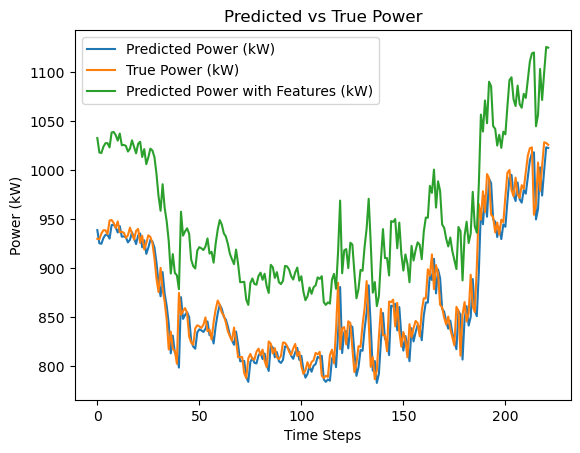

In [241]:
# plot the predictions and the true values
import matplotlib.pyplot as plt
predicted_values = [predictions_for_january[time]['predicted_power_kw'] for time in predictions_for_january]
true_values = [predictions_for_january[time]['true_power_kw'] for time in predictions_for_january]
predicted_values_90 = [predictions_for_january_90[time]['predicted_power_kw'] for time in predictions_for_january_90]
plt.plot(predicted_values, label='Predicted Power (kW)')
plt.plot(true_values, label='True Power (kW)')
plt.plot(predicted_values_90, label='Predicted Power with Features (kW)')
plt.xlabel('Time Steps')
plt.ylabel('Power (kW)')
plt.title('Predicted vs True Power')
plt.legend()
plt.show()

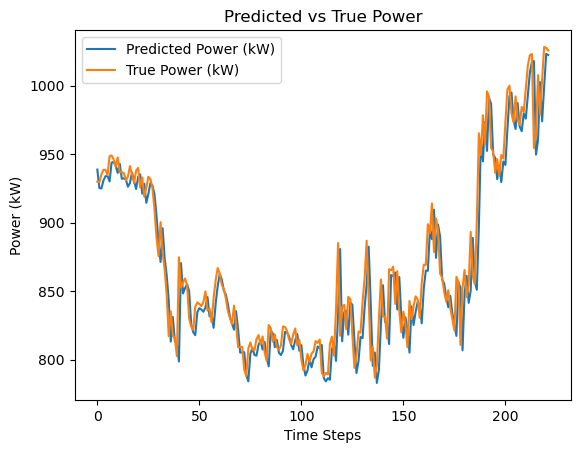

MAE:  14.301193856772104


In [ ]:
# predictions_for_january
# plot the predictions and the true values
import matplotlib.pyplot as plt
predicted_values = [predictions_for_january[time]['predicted_power_kw'] for time in predictions_for_january]
true_values = [predictions_for_january[time]['true_power_kw'] for time in predictions_for_january]
plt.plot(predicted_values, label='Predicted Power (kW)')
plt.plot(true_values, label='True Power (kW)')
plt.xlabel('Time Steps')
plt.ylabel('Power (kW)')
plt.title('Predicted vs True Power')
plt.legend()
plt.show()
# the mae score for the predictions
mae = sum([abs(predictions_for_january[time]['predicted_power_kw'] - predictions_for_january[time]['true_power_kw']) for time in predictions_for_january]) / len(predictions_for_january)
print("MAE: ", mae)

In [243]:
torch.save(model.state_dict(), 'generator_model.pth')
#save the csv file with the predictions
prediction = {
    'timestamp': [time for time in predictions_for_january],
    'pred_power_kw': [predictions_for_january[time]['predicted_power_kw'] for time in predictions_for_january],
    'pred_p90_kw': [predictions_for_january_90[time]['predicted_power_kw'] for time in predictions_for_january_90]    
}
predictions_df = pd.DataFrame.from_dict(predictions_for_january, orient='index')
predictions_df.to_csv('predictions_for_january_with_p90.csv')

In [120]:
feature_params

[Parameter containing:
 tensor(0.1000, requires_grad=True)]

In [114]:
print("our input was: ", power_kw, "and our prediction is: ", outputs.detach().numpy(), "and the true value is: ", power_pred)

our input was:  [[843.24734497]] and our prediction is:  [[866.4525]] and the true value is:  [[866.86591945]]


In [97]:
power_kw.shape

(24,)